In [1]:
import numpy as np
import matplotlib.pyplot as plt

from phase import PhaseSolver, PhaseConfig

def correct(frame, mask):
    ys, xs = np.where(mask)
    corr = frame.astype(float).copy()
    for y, x in zip(ys, xs):
        nb  = frame[max(0,y-1):y+2, max(0,x-1):x+2]
        nbm = mask [max(0,y-1):y+2, max(0,x-1):x+2]
        good = nb[~nbm]
        if good.size: corr[y,x] = np.median(good)
    return corr

N = 20

# Exposure 200 ms

In [2]:
# Read dark frames
data_dark_200 = np.load("../../data/dark_200_20260907_134836.npz")
stack_dark_200 = data_dark_200['stack'][0]

In [3]:
# Find and correct for hot pixels
frames = stack_dark_200            # (N,H,W), same gain+exposure as your data

m = frames.mean(0)                 # per-pixel mean  -> high dark current
s = frames.std(0)                  # per-pixel std   -> RTS/flicker

def rob(x, k=5):                   # robust threshold, unbiased by outliers
    med = np.median(x)
    mad = np.median(np.abs(x-med))*1.4826
    return np.abs(x-med) >= k*mad

mask = rob(m) | rob(s)             # (H,W) bool, True = hot
print(100*mask.mean(), "% hot")

stack_dark_200_corr = np.stack([correct(stack_dark_200[n], mask) for n in range(len(stack_dark_200))])
stack_dark_200_ref = stack_dark_200_corr.mean(axis=0)

0.10300275482093664 % hot


In [4]:
# Read ref bright frames
data_ref_bright_200 = np.load("../../data/piezo_sample_bright_200_20260907_135232.npz")
stack_ref_bright_200 = data_ref_bright_200['stack'][0][:N]

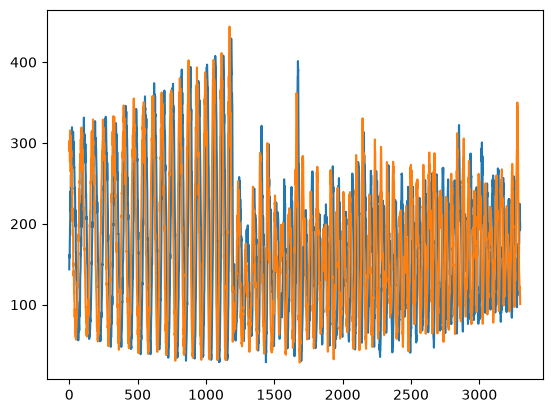

In [5]:
# Correct for hot pixels and subtract dark
stack_ref_bright_200_corr = np.stack([correct(stack_ref_bright_200[n], mask) for n in range(len(stack_ref_bright_200))])
stack_ref_bright_200_corr = np.maximum(stack_ref_bright_200_corr - stack_dark_200_ref, 0)

plt.plot(stack_ref_bright_200_corr[0,1000])
plt.plot(stack_ref_bright_200_corr[3,1000])

In [6]:
# Compute noise
sigma_n = np.sqrt(stack_ref_bright_200_corr*2.6596) / 2.6596    # (N,P), gain=100
sigma_pixel = np.sqrt((sigma_n**2).mean(0))          # (P,)

rms_ref_bright_200 = np.sqrt((sigma_pixel**2).mean())
noise_floor_ref_bright_200 = np.sqrt((sigma_pixel**2).mean()) / stack_ref_bright_200_corr.std()

print(f"RMS noise: {rms_ref_bright_200}")
print(f"Noise floor: {noise_floor_ref_bright_200}")

RMS noise: 8.364947850460425
Noise floor: 0.08804754637711171


In [10]:
iters = 30
tol = 1e-4
refine_iters = 20
refine_tol = 1e-4

results = {}
for degree in (0,2):
    cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
    cfg_d.use_alpha = True
    cfg_d.gain_mode = "joint"
    cfg_d.precise_reduce = False
    cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=degree,
                                refine_iters=refine_iters, refine_tol=refine_tol)
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_200_corr)
    results[degree] = solver_d
    mp = solver_d.method_param_
    print(f"degree={degree} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
          f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
          f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

degree=0 converged=False  reconstruction_error=16.4575  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
degree=2 converged=True  reconstruction_error=8.3902  kappa_fit=2.18  refine_iters_run=6  rms_frac_history=['0.09693', '0.09263', '0.08638', '0.08544', '0.08524', '0.08518']


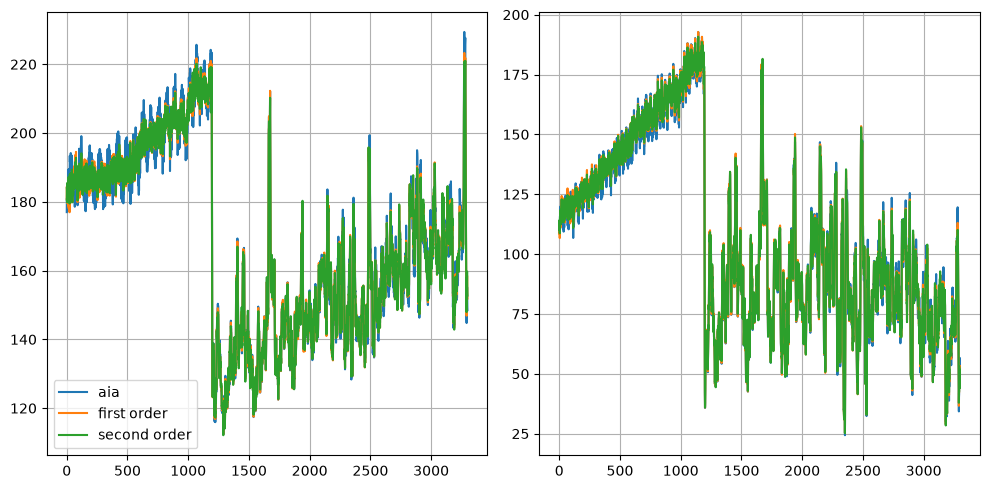

In [30]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(results[0].result_.a[1000], label="aia")
plt.plot(results[1].result_.a[1000], label="first order")
plt.plot(results[2].result_.a[1000], label="second order")
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(results[0].result_.b[1000])
plt.plot(results[1].result_.b[1000])
plt.plot(results[2].result_.b[1000])
plt.grid()

plt.tight_layout()

In [ ]:
num_range = np.arange(start=5, stop=20)
iters = 30
tol = 1e-4
refine_iters = 20
refine_tol = 1e-4

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = True
cfg_d.gain_mode = "joint"
cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=2,
                            refine_iters=refine_iters, refine_tol=refine_tol)

results = {}
for num in num_range:
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_200_corr[:num])
    results[num] = solver_d
    mp = solver_d.method_param_
    print(f"num={num} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
            f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
            f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

Text(8, 0.086, 'Noise floor')

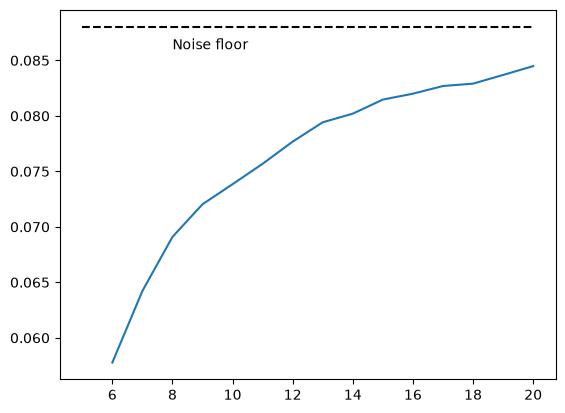

In [46]:
plt.plot(num_range+1, [results[num].method_param_.rms_frac for num in num_range])
plt.hlines(noise_floor_ref_bright_200, 5, 20, color='k', linestyles='--')
plt.text(8,0.086, "Noise floor")

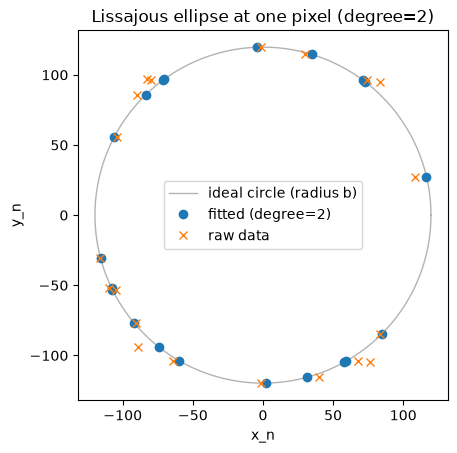

In [31]:
from phase.methods.step_field import _poly_basis

degree = 2                                        # pick which results[...] fit to inspect
r = results[degree].result_
mp = results[degree].method_param_
a_, b_, phi_ = r.a, r.b, r.phi
u_ = b_ * np.cos(phi_)
v_ = -b_ * np.sin(phi_)

i = a_.size // 2                                  # a pixel index (flat)
row, col = np.unravel_index(i, a_.shape)
u_i, v_i = u_[row, col], v_[row, col]
b_i = np.hypot(u_i, v_i)

# The degree-2 model's actual per-frame step AT THIS PIXEL, not the plain
# piston delta -- delta_n(x,y) = delta_n + coeffs[:,n] @ basis(x,y)
# (docs/step_field_residuals.md Eq. T1), evaluated at (row, col) only (no
# need to build the full (N,H,W) field for one pixel).
basis = _poly_basis(*a_.shape, degree, np)        # (J, P)
basis_i = basis[:, i]                             # (J,) -- this pixel's basis values
delta_eff = r.delta + mp.coeffs.T @ basis_i        # (N,) -- this pixel's true step

xn = u_i * np.cos(delta_eff) + v_i * np.sin(delta_eff)   # fitted x_n, degree-2 model
yn = u_i * np.sin(delta_eff) - v_i * np.cos(delta_eff)   # quadrature

# Raw experimental x_n at the same pixel, alpha/g-corrected the same way the
# model is (I_n = alpha_n*(a + g_n*(u*cos(delta_n)+v*sin(delta_n)))) -- paired
# with the *model's* yn, since a single-channel intensity sample only gives
# one real number per frame, not an independent (x,y) pair. Points straying
# off the fitted circle are frames where the raw data disagrees with what
# the degree-2 fit predicts -- this is the actual "how good is my model"
# check, now that the reference uses the fitted step field, not the piston.
xn_raw = (stack_ref_bright_200_corr[:, row, col] / r.alpha - a_[row, col]) / r.g

theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(b_i * np.cos(theta), b_i * np.sin(theta), '-', color='0.7', lw=1,
         label='ideal circle (radius b)')
plt.plot(xn, yn, 'o', label=f'fitted (degree={degree})')
plt.plot(xn_raw, yn, 'x', label='raw data')
plt.gca().set_aspect('equal')
plt.xlabel('x_n')
plt.ylabel('y_n')
plt.title(f'Lissajous ellipse at one pixel (degree={degree})')
plt.legend()

In [32]:
from phase.backend import wrap

xr, yr = xn_raw, yn          # yr still comes from the model -- see the note in the cell above
th = np.arctan2(yr, xr)
rad = np.hypot(xr, yr)

print("radial scatter (amp err):", np.std(rad) / b_i)                # alpha/g miscalibration, noise
print("angular scatter (delta err):", np.std(wrap(th - delta_eff)))  # phase-step (delta_n) error

radial scatter (amp err): 0.03645234782212006
angular scatter (delta err): 0.05030334454153153


# Exposure 400 ms

In [47]:
# Read dark frames
data_dark_400 = np.load("../../data/dark_400_20260907_134803.npz")
stack_dark_400 = data_dark_400['stack'][0]

In [48]:
# Find and correct for hot pixels
frames = stack_dark_400            # (N,H,W), same gain+exposure as your data

m = frames.mean(0)                 # per-pixel mean  -> high dark current
s = frames.std(0)                  # per-pixel std   -> RTS/flicker

def rob(x, k=5):                   # robust threshold, unbiased by outliers
    med = np.median(x)
    mad = np.median(np.abs(x-med))*1.4826
    return np.abs(x-med) >= k*mad

mask = rob(m) | rob(s)             # (H,W) bool, True = hot
print(100*mask.mean(), "% hot")

stack_dark_400_corr = np.stack([correct(stack_dark_400[n], mask) for n in range(len(stack_dark_400))])
stack_dark_400_ref = stack_dark_400_corr.mean(axis=0)

0.0750137741046832 % hot


In [49]:
# Read ref bright frames
data_ref_bright_400 = np.load("../../data/piezo_sample_bright_400_20260907_135149.npz")
stack_ref_bright_400 = data_ref_bright_400['stack'][0]

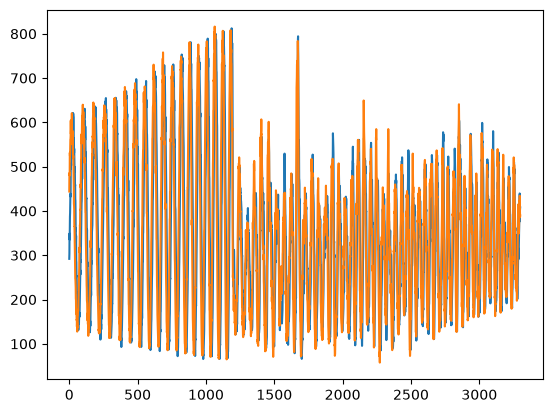

In [50]:
# Correct for hot pixels and subtract dark
stack_ref_bright_400_corr = np.stack([correct(stack_ref_bright_400[n], mask) for n in range(len(stack_ref_bright_400))])
stack_ref_bright_400_corr = np.maximum(stack_ref_bright_400_corr - stack_dark_400_ref, 0)

plt.plot(stack_ref_bright_400_corr[0,1000])
plt.plot(stack_ref_bright_400_corr[1,1000])

In [51]:
# Compute noise
sigma_n = np.sqrt(stack_ref_bright_400_corr*2.6596) / 2.6596    # (N,P), gain=100
sigma_pixel = np.sqrt((sigma_n**2).mean(0))          # (P,)

rms_ref_bright_400 = np.sqrt((sigma_pixel**2).mean())
noise_floor_ref_bright_400 = np.sqrt((sigma_pixel**2).mean()) / stack_ref_bright_400_corr.std()

print(f"RMS noise: {rms_ref_bright_400}")
print(f"Noise floor: {noise_floor_ref_bright_400}")

RMS noise: 11.875078831085956
Noise floor: 0.061194304980116215


In [ ]:
iters = 30
tol = 1e-4
refine_iters = 20
refine_tol = 1e-4

results = {}
for degree in (0, 1, 2):
    cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
    cfg_d.use_alpha = True
    cfg_d.gain_mode = "joint"
    cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=degree,
                                refine_iters=refine_iters, refine_tol=refine_tol)
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_400_corr)
    results[degree] = solver_d
    mp = solver_d.method_param_
    print(f"degree={degree} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
          f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
          f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

degree=0 converged=False  reconstruction_error=24.1711  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
degree=1 converged=True  reconstruction_error=14.1619  kappa_fit=1.17  refine_iters_run=4  rms_frac_history=['0.07443', '0.06986', '0.06944', '0.06934']
degree=2 converged=True  reconstruction_error=11.8711  kappa_fit=2.25  refine_iters_run=6  rms_frac_history=['0.06604', '0.06024', '0.05944', '0.05918', '0.05907', '0.05901']
degree=3 converged=True  reconstruction_error=11.6485  kappa_fit=3.67  refine_iters_run=6  rms_frac_history=['0.06526', '0.05930', '0.05850', '0.05827', '0.05815', '0.05810']


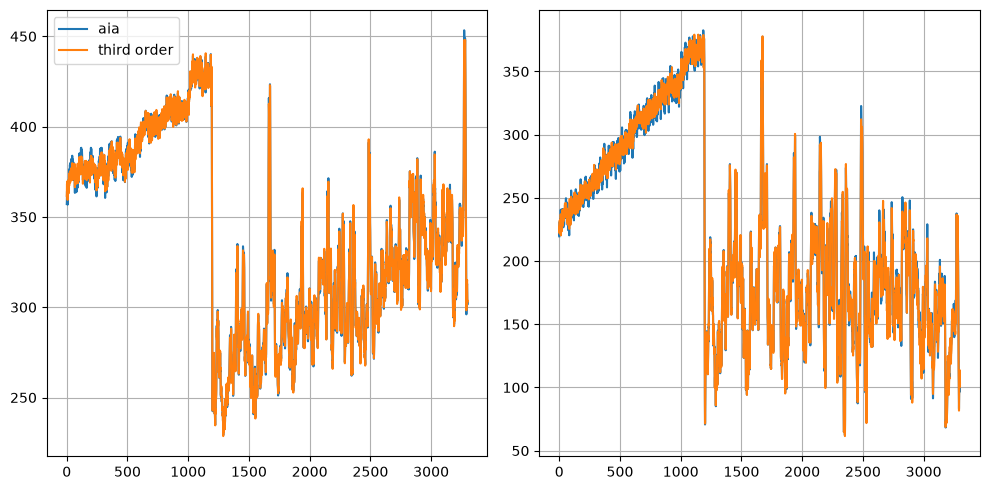

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(results[0].result_.a[1000], label="aia")
plt.plot(results[2].result_.a[1000], label="second order")
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(results[0].result_.b[1000])
plt.plot(results[2].result_.b[1000])
plt.grid()

plt.tight_layout()

In [52]:
num_range = np.arange(start=5, stop=20)
iters = 30
tol = 1e-4
refine_iters = 20
refine_tol = 1e-4

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = True
cfg_d.gain_mode = "joint"
cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=2,
                            refine_iters=refine_iters, refine_tol=refine_tol)

results = {}
for num in num_range:
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_400_corr[:num])
    results[num] = solver_d
    mp = solver_d.method_param_
    print(f"num={num} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
            f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
            f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

num=5 converged=True  reconstruction_error=7.7737  kappa_fit=2.36  refine_iters_run=7  rms_frac_history=['0.04372', '0.04061', '0.03948', '0.03891', '0.03866', '0.03854', '0.03848']
num=6 converged=True  reconstruction_error=8.7140  kappa_fit=2.35  refine_iters_run=6  rms_frac_history=['0.04760', '0.04547', '0.04453', '0.04413', '0.04395', '0.04385']
num=7 converged=True  reconstruction_error=9.4095  kappa_fit=2.37  refine_iters_run=6  rms_frac_history=['0.05161', '0.04865', '0.04777', '0.04745', '0.04730', '0.04721']
num=8 converged=True  reconstruction_error=9.8559  kappa_fit=2.3  refine_iters_run=7  rms_frac_history=['0.05897', '0.05253', '0.05041', '0.04977', '0.04952', '0.04939', '0.04933']
num=9 converged=True  reconstruction_error=10.1818  kappa_fit=2.29  refine_iters_run=7  rms_frac_history=['0.06001', '0.05453', '0.05208', '0.05148', '0.05123', '0.05108', '0.05102']
num=10 converged=True  reconstruction_error=10.4770  kappa_fit=2.29  refine_iters_run=5  rms_frac_history=['0.05

Text(8, 0.059, 'Noise floor')

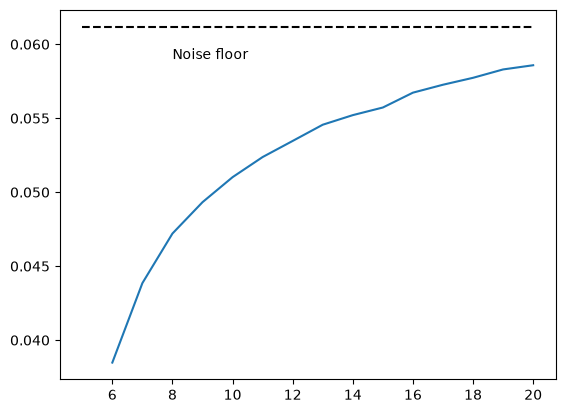

In [55]:
plt.plot(num_range+1, [results[num].method_param_.rms_frac for num in num_range])
plt.hlines(noise_floor_ref_bright_400, 5, 20, color='k', linestyles='--')
plt.text(8,0.059, "Noise floor")

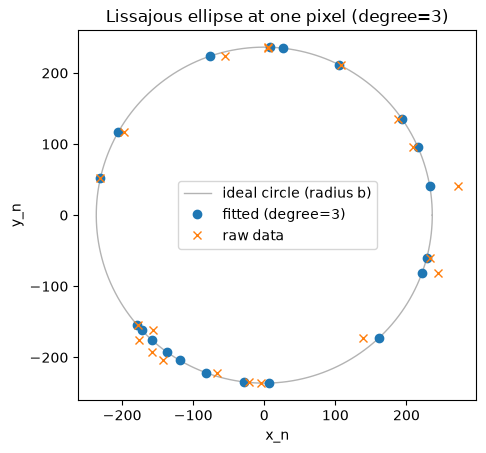

In [40]:
from phase.methods.step_field import _poly_basis

degree = 3                                        # pick which results[...] fit to inspect
r = results[degree].result_
mp = results[degree].method_param_
a_, b_, phi_ = r.a, r.b, r.phi
u_ = b_ * np.cos(phi_)
v_ = -b_ * np.sin(phi_)

i = a_.size // 2                                  # a pixel index (flat)
row, col = np.unravel_index(i, a_.shape)
u_i, v_i = u_[row, col], v_[row, col]
b_i = np.hypot(u_i, v_i)

# The degree-2 model's actual per-frame step AT THIS PIXEL, not the plain
# piston delta -- delta_n(x,y) = delta_n + coeffs[:,n] @ basis(x,y)
# (docs/step_field_residuals.md Eq. T1), evaluated at (row, col) only (no
# need to build the full (N,H,W) field for one pixel).
basis = _poly_basis(*a_.shape, degree, np)        # (J, P)
basis_i = basis[:, i]                             # (J,) -- this pixel's basis values
delta_eff = r.delta + mp.coeffs.T @ basis_i        # (N,) -- this pixel's true step

xn = u_i * np.cos(delta_eff) + v_i * np.sin(delta_eff)   # fitted x_n, degree-2 model
yn = u_i * np.sin(delta_eff) - v_i * np.cos(delta_eff)   # quadrature

# Raw experimental x_n at the same pixel, alpha/g-corrected the same way the
# model is (I_n = alpha_n*(a + g_n*(u*cos(delta_n)+v*sin(delta_n)))) -- paired
# with the *model's* yn, since a single-channel intensity sample only gives
# one real number per frame, not an independent (x,y) pair. Points straying
# off the fitted circle are frames where the raw data disagrees with what
# the degree-2 fit predicts -- this is the actual "how good is my model"
# check, now that the reference uses the fitted step field, not the piston.
xn_raw = (stack_ref_bright_400_corr[:, row, col] / r.alpha - a_[row, col]) / r.g

theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(b_i * np.cos(theta), b_i * np.sin(theta), '-', color='0.7', lw=1,
         label='ideal circle (radius b)')
plt.plot(xn, yn, 'o', label=f'fitted (degree={degree})')
plt.plot(xn_raw, yn, 'x', label='raw data')
plt.gca().set_aspect('equal')
plt.xlabel('x_n')
plt.ylabel('y_n')
plt.title(f'Lissajous ellipse at one pixel (degree={degree})')
plt.legend()

In [41]:
xr, yr = xn_raw, yn          # yr still comes from the model -- see the note in the cell above
th = np.arctan2(yr, xr)
rad = np.hypot(xr, yr)

print("radial scatter (amp err):", np.std(rad) / b_i)                # alpha/g miscalibration, noise
print("angular scatter (delta err):", np.std(wrap(th - delta_eff)))  # phase-step (delta_n) error

radial scatter (amp err): 0.05136305878456659
angular scatter (delta err): 0.04779927826426267


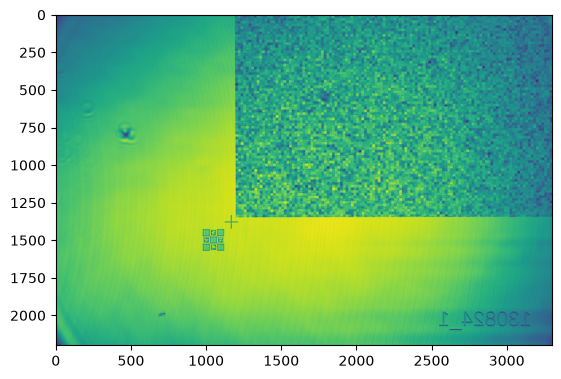

In [51]:
plt.imshow(results[3].result_.b/results[3].result_.a)
# plt.xlim([500, 1500])
# plt.ylim([1750, 1250])

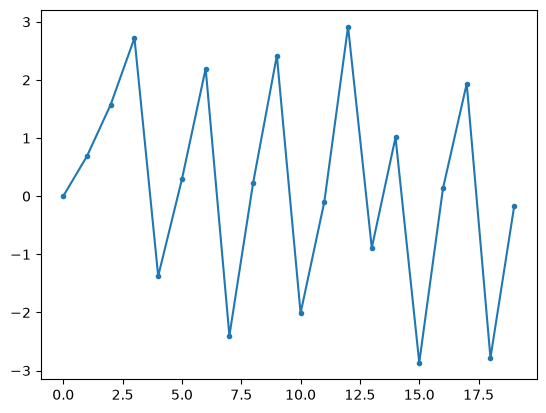

In [62]:
plt.plot(results[3].result_.delta, '.-')

In [67]:
results[3].method_param_

StepFieldParam(aia_param=AIAParam(kappa_p=2.8191986794594732, kappa_ps=2.000810119631153, predicted_rms=np.float64(0.03620804055289385), iters_run=4, converged=True, g_fit=array([1.00105167, 1.00539533, 1.0087526 , 1.01260055, 1.00732579,
       0.90239437, 1.0003711 , 0.99780914, 0.97206278, 0.99720152,
       1.00586906, 1.0000571 , 0.99489988, 0.99376884, 0.99713277,
       1.00585703, 1.00264399, 0.9999429 , 0.99350416, 0.99797977]), c_fit=array([-0.03129171, -0.01308825,  0.01523654,  0.04844011, -0.03533833,
        0.00528066,  0.00190005,  0.03728567, -0.08160314,  0.02658717,
       -0.01206635,  0.03662111, -0.02396854,  0.05340033, -0.04052169,
       -0.00863938,  0.01641824,  0.01292168, -0.06248158,  0.05490739]), g_min_ratio=0.9023943673684416), degree=3, coeffs=array([[ 1.41616041e+02, -3.78036984e+01,  1.66229444e+02,
         1.56567386e+02,  1.10277530e+02, -6.35276717e+01,
        -3.98632902e+02,  2.92540159e+02,  5.30049380e+02,
         4.09246692e+02,  6.7757822

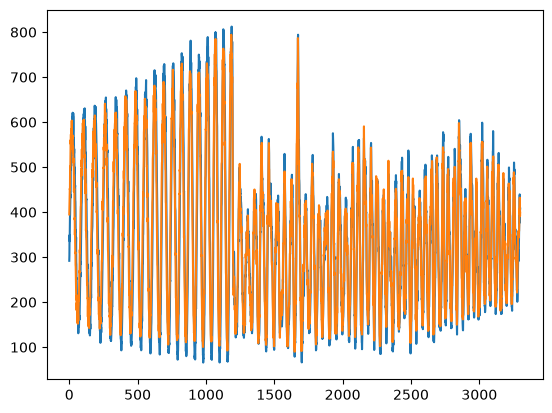

In [58]:
plt.plot(stack_ref_bright_400_corr[0,1000])
plt.plot(stack_ref_bright_400_corr[5,1000])